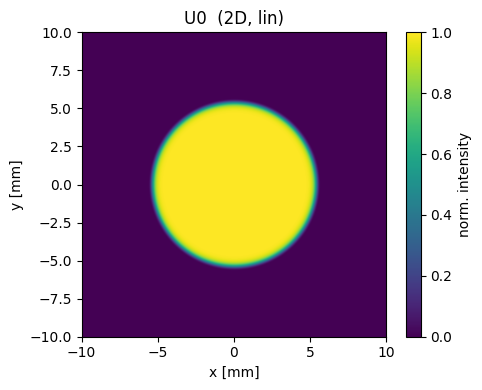

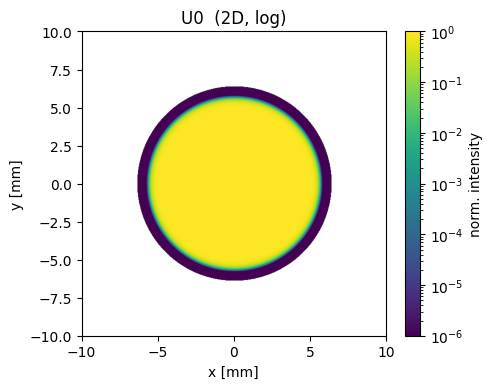

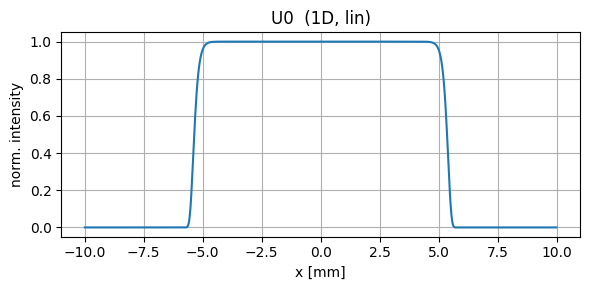

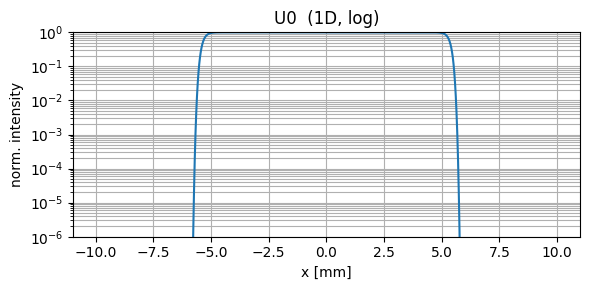

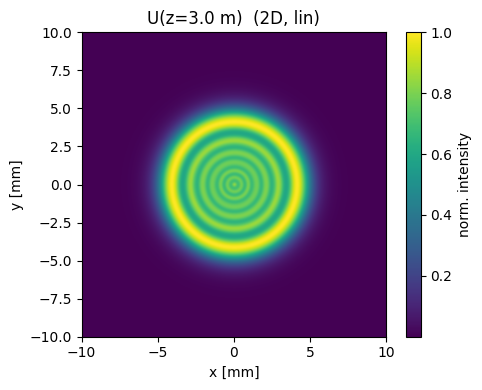

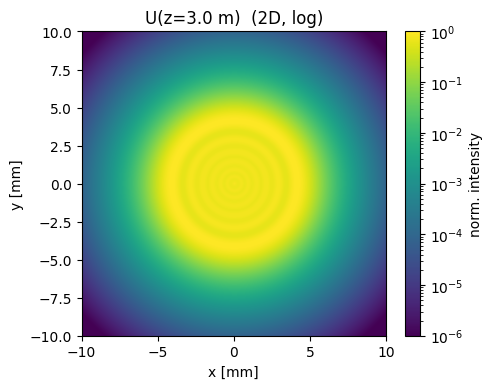

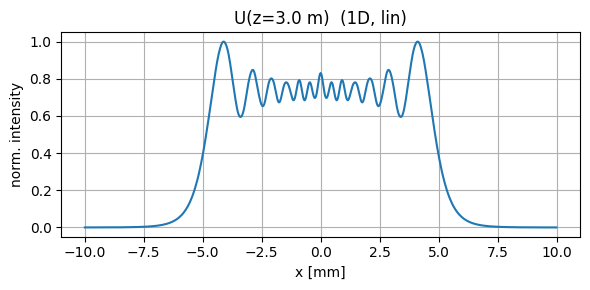

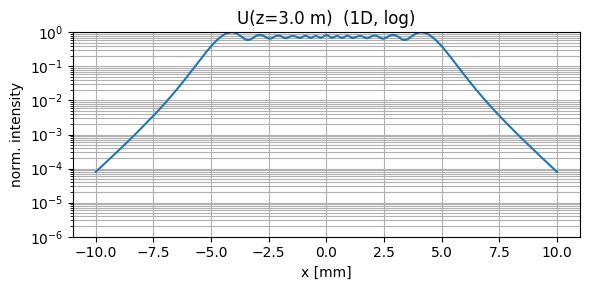

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ==============================================================
# 1) Physik & Gitter
# ==============================================================
lam = 800e-9            # Wellenlänge [m]
BEAM_DIAM = 11e-3       # Strahldurchmesser [m]

N = 1024
L = 3 * BEAM_DIAM
dx = L / N
x = (np.arange(N) - N/2) * dx
y = x
X, Y = np.meshgrid(x, y)

# ==============================================================
# 2) Startfeld: Super-Gauss (Flat-Top-ähnlich)
# ==============================================================
def make_supergauss(n=40):
    w0 = BEAM_DIAM / 2
    R = np.sqrt(X**2 + Y**2)
    return np.exp(-(R / w0)**n).astype(complex)

# ==============================================================
# 3) Angular Spectrum Propagation
# ==============================================================
def propagate_asm(U0, z):
    k = 2*np.pi / lam

    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k**2 - kx**2 - ky**2 + 0j)

    H = np.exp(1j * kz * z)

    U_k = np.fft.fft2(U0)
    Uz = np.fft.ifft2(U_k * H)
    return Uz

# ==============================================================
# 4) 2D Plot
# ==============================================================
def plot_2d(U, title="", zoom_mm=10.0, log=False):
    I = np.abs(U)**2
    I /= I.max()

    x_mm = x * 1e3
    y_mm = y * 1e3

    m = np.abs(x_mm) <= zoom_mm
    I_zoom = I[np.ix_(m, m)]

    extent = [-zoom_mm, zoom_mm, -zoom_mm, zoom_mm]

    plt.figure(figsize=(5,4))
    if log:
        plt.imshow(I_zoom, extent=extent, origin="lower",
                   norm=LogNorm(vmin=1e-6, vmax=1), aspect="equal")
    else:
        plt.imshow(I_zoom, extent=extent, origin="lower", aspect="equal")

    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    plt.title(title)
    plt.colorbar(label="norm. intensity")
    plt.tight_layout()
    plt.show()

# ==============================================================
# 5) 1D Plot (mittlerer Schnitt)
# ==============================================================
def plot_1d(U, title="", zoom_mm=10.0, log=False):
    I = np.abs(U)**2
    I /= I.max()

    mid = N//2
    I1d = I[mid, :]
    x_mm = x * 1e3

    m = np.abs(x_mm) <= zoom_mm
    x_plot = x_mm[m]
    I_plot = I1d[m]

    plt.figure(figsize=(6,3))
    plt.plot(x_plot, I_plot)
    if log:
        plt.yscale("log")
        plt.ylim(1e-6, 1)

    plt.xlabel("x [mm]")
    plt.ylabel("norm. intensity")
    plt.title(title)
    plt.grid(True, which="both")
    plt.tight_layout()
    plt.show()

# ==============================================================
# 6) Demo
# ==============================================================
if __name__ == "__main__":

    U0 = make_supergauss(n=40)

    z = 3.0   # 3 m freie Propagation
    Uz = propagate_asm(U0, z)

    # --- Startfeld ---
    plot_2d(U0, "U0  (2D, lin)", zoom_mm=10, log=False)
    plot_2d(U0, "U0  (2D, log)", zoom_mm=10, log=True)
    plot_1d(U0, "U0  (1D, lin)", zoom_mm=10, log=False)
    plot_1d(U0, "U0  (1D, log)", zoom_mm=10, log=True)

    # --- Propagiert ---
    plot_2d(Uz, f"U(z={z} m)  (2D, lin)", zoom_mm=10, log=False)
    plot_2d(Uz, f"U(z={z} m)  (2D, log)", zoom_mm=10, log=True)
    plot_1d(Uz, f"U(z={z} m)  (1D, lin)", zoom_mm=10, log=False)
    plot_1d(Uz, f"U(z={z} m)  (1D, log)", zoom_mm=10, log=True)
